In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pygam as gm
import copy as cp

In [9]:
mydf.drop(columns=['depth'])

,age,Abies,Pinus,Juniperus,Taxus,Alnus,Acer,Betula,Castanea,Corylus,...,Juncaceae,Ranunculaceae t Ranunculus,Sparganium,Typha,Callitriche,Myriophyllum,Nymphaea,Potamogeton,Utricularia,Undetermined
0,863,199.439215,437.899147,69.370162,0.0,0.000000,0.000000,30.349446,0.000000,26.013811,...,34.685081,17.342540,0.000000,0.000000,13.006905,13.006905,17.342540,0.000000,0.0,177.761040
1,959,266.830454,695.163550,84.262248,0.0,0.000000,0.000000,21.065562,0.000000,21.065562,...,0.000000,7.021854,0.000000,0.000000,0.000000,0.000000,56.174832,0.000000,0.0,0.000000
2,1020,282.078022,789.818462,43.878803,0.0,25.073602,0.000000,31.342002,0.000000,37.610403,...,18.805201,18.805201,0.000000,0.000000,0.000000,0.000000,50.147204,0.000000,0.0,87.757607
3,1077,255.733515,558.825089,142.074175,0.0,9.471612,0.000000,47.358058,9.471612,18.943223,...,37.886447,18.943223,37.886447,0.000000,0.000000,0.000000,208.375457,0.000000,0.0,161.017398
4,1106,463.370907,549.762093,125.659907,0.0,70.683698,15.707488,31.414977,0.000000,78.537442,...,62.829953,0.000000,0.000000,0.000000,0.000000,0.000000,70.683698,0.000000,0.0,70.683698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,10621,0.000000,490.165091,30.635318,0.0,0.000000,0.000000,1286.683363,0.000000,189.938973,...,0.000000,12.254127,0.000000,0.000000,12.254127,24.508255,0.000000,6.127064,0.0,36.762382
77,10843,0.000000,446.514810,4.212404,0.0,0.000000,0.000000,631.860580,0.000000,147.434135,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,25.274423
78,11106,5.612543,1150.571285,11.225086,0.0,0.000000,0.000000,611.767171,0.000000,106.638314,...,0.000000,11.225086,0.000000,0.000000,0.000000,5.612543,0.000000,0.000000,0.0,101.025771
79,11280,0.000000,898.457665,62.269343,0.0,0.000000,0.000000,1183.117519,0.000000,373.616059,...,17.791241,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,71.164964


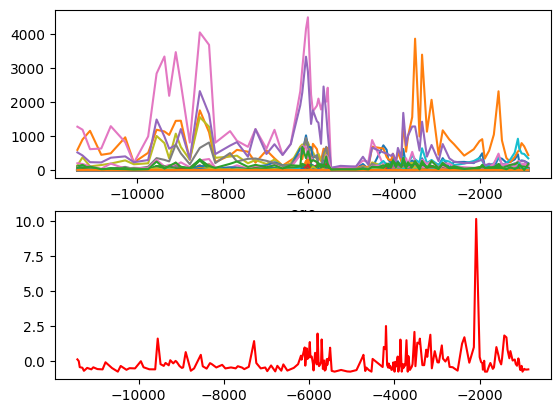

In [ ]:
dirdatain = './data/'

database = 'tramacastilla' # vinuelas, brezoso

if database == 'tramacastilla':
    results = 'results_tramacastilla'
    mydf = pd.read_csv(dirdatain+'tramacastilla/tram20_PAR.csv').drop(columns=['depth']).sort_values(by='age', ascending=False)
    CHAR = pd.read_csv(dirdatain+'tramacastilla/tram_charcoal_zscores.csv').sort_values(by='age', ascending=False)

    mydf['age'] = -mydf['age']
    CHAR['age'] = -CHAR['age']

    # functional_groups = ? 
# twin axes
fig,(ax,ax2) = plt.subplots(2,1)
# ax2 = ax.twinx()
mydf.plot(x='age', ax=ax, legend=False)
ax2.plot(CHAR['age'], CHAR['CHAR.z_scores'], color='red')

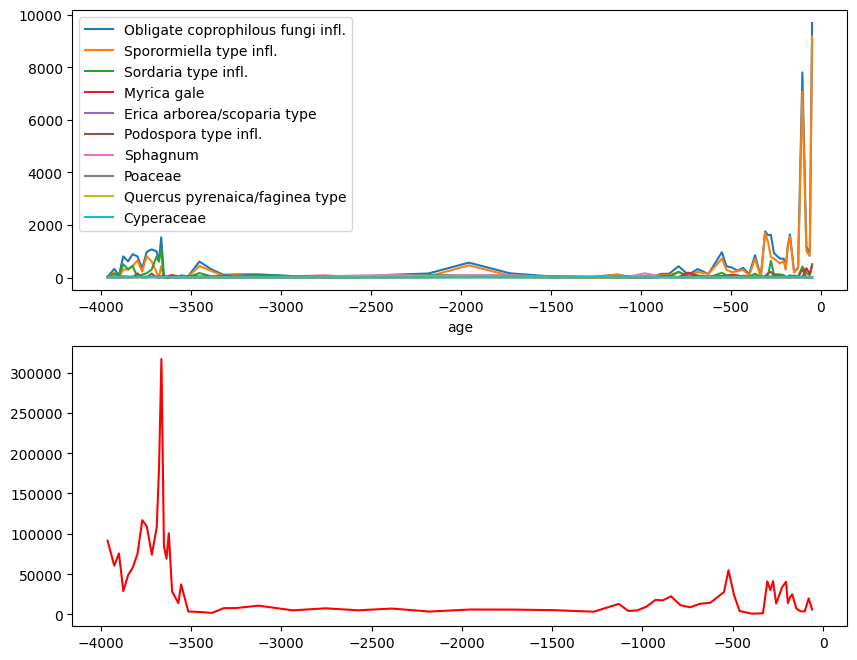

In [103]:
database = 'brezoso'
if database == 'brezoso':
    results = 'results_brezoso'
    mydf = pd.read_csv(dirdatain+'brezoso/pollen.csv').drop(columns=['depth','accrate',
                                                                    'Charcoal concentration (# cm-3)', 'CHAR (# cm-2 yr-1)',
                                                                    'Nr Lycopodium spores/tablet', 'Unnamed: 167',
                                                                    'Unnamed: 170', 'Lycopodium exotic marker pollen',
                                                                    'Lycopodium tablets', 'Unidentified','Volume (cm3)','Unnamed: 176'
                                                                    ]
            ).sort_values(by='age', ascending=False)

    CHAR = pd.read_csv(dirdatain+'brezoso/CHAR.csv').sort_values(by='age', ascending=False)

    mydf['age'] = -mydf['age']
    CHAR['age'] = -CHAR['age']

    #____________________FUNCTIONAL GROUPS_________________
    functional_groups = pd.read_csv(dirdatain+'brezoso/dictionary.csv')
    functional_groups['Community_int'] = functional_groups['functional group'].astype('category').cat.codes
    functional_partition = functional_groups.set_index('taxa').to_dict()['Community_int']
    community_index = functional_groups.set_index('functional group').to_dict()['Community_int']
    community_index_T = {v: k for k, v in community_index.items()}
    #______________________________________________________

    # check every species in functional groups is in mydf
    for taxon in functional_groups['taxa']:
        if taxon not in mydf.columns:
            print(taxon)
    # and viceversa
    for taxon in mydf.columns:
        if taxon not in functional_groups['taxa'].values and taxon != 'age':
            print(taxon)

fig,(ax,ax2)=plt.subplots(2,1, figsize=(10,8))
# take the 10 columns with highest sums
top10 =mydf.sum().sort_values(ascending=False).index[0:10].to_list()
mydf[['age']+top10].plot(x='age', ax=ax)
ax2.plot(CHAR['age'], CHAR['CHAR (# cm-2 yr-1)'], color='red')

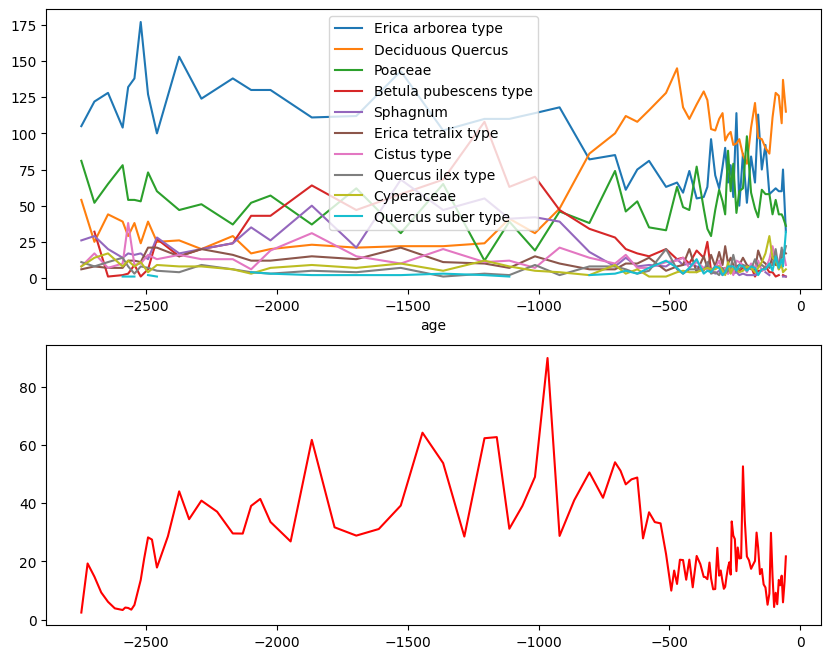

In [128]:
database = 'vinuelas'
if database == 'vinuelas':
    results = 'results_vinuelas'
    mydf = pd.read_csv(dirdatain+'vinuelas/pollen.csv').drop(columns=['depth', 'Unidentified', 'Lycopodium (exotic marker)',
    'Volume (cm3)', 'Lycopodium tablets', 'Nr Lycopodium spores/tablet', 'Charcoal counts (#)', 'Lycopodium charcoal'])
            # ).sort_values(by='age', ascending=False)

    CHAR = pd.read_csv(dirdatain+'vinuelas/CHAR.csv').sort_values(by='age', ascending=False)

    mydf['age'] = -mydf['age']
    CHAR['age'] = -CHAR['age']

    #____________________FUNCTIONAL GROUPS_________________
    functional_groups = pd.read_csv(dirdatain+'vinuelas/dictionary.csv')
    functional_groups['Community_int'] = functional_groups['functional_group'].astype('category').cat.codes
    functional_partition = functional_groups.set_index('taxa').to_dict()['Community_int']
    community_index = functional_groups.set_index('functional_group').to_dict()['Community_int']
    community_index_T = {v: k for k, v in community_index.items()}
    #______________________________________________________

    # check every species in functional groups is in mydf
    for taxon in functional_groups['taxa']:
        if taxon not in mydf.columns:
            print(taxon)
    # and viceversa
    missing_taxa = ''
    for taxon in mydf.columns:
        if taxon not in functional_groups['taxa'].values and taxon != 'age':
            missing_taxa += taxon + ', '
    print(missing_taxa)

fig,(ax,ax2)=plt.subplots(2,1, figsize=(10,8))
# take the 10 columns with highest sums
top10 =mydf.sum().sort_values(ascending=False).index[0:10].to_list()
mydf[['age']+top10].plot(x='age', ax=ax)
ax2.plot(CHAR['age'], CHAR['Macroscopic CHAR (# cm-2 yr-1)'], color='red')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

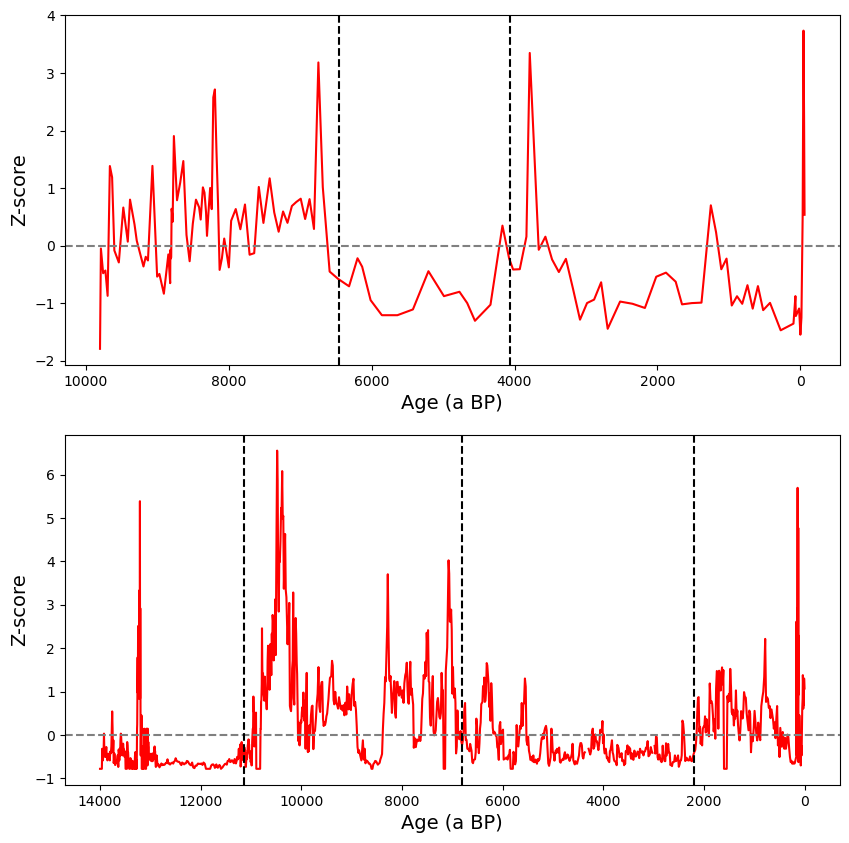

In [43]:
# zscore for basa de la mora and garba guracha (GG)

basa_zscore = pd.read_csv("../data/bsm_charcoal_zscores.csv")
#z-score the CHAR
basa_zscore = basa_zscore[['Age BP', 'Z-SCORES']]
basa_zscore = basa_zscore.sort_values(by='Age BP', ascending=False)

fig,[ax,ax1] = plt.subplots(2,1,figsize=(10,10))
basa_zscore.plot(x='Age BP', y='Z-SCORES', color='red', ax=ax, legend=False)
#flip x axis
ax.invert_xaxis()
#horizontal line at zero
ax.axhline(0, color='grey', linestyle='--')
#vertical line at 6300
ax.axvline(6460, color='black', linestyle='--')
ax.axvline(4070, color='black', linestyle='--')

GG_zscore = pd.read_csv("../data_GG/charcoal_age_v2.csv")
GG_zscore = GG_zscore[['ka.BP', 'CHAR']]
# make char zscores
GG_zscore['CHAR'] = (GG_zscore['CHAR'] - GG_zscore['CHAR'].mean()) / GG_zscore['CHAR'].std()
GG_zscore['Age BP'] = GG_zscore['ka.BP'] * 1000
GG_zscore = GG_zscore[GG_zscore['Age BP'] <= 14000]
GG_zscore = GG_zscore.sort_values(by='Age BP', ascending=False)

GG_zscore.plot(x='Age BP', y='CHAR', color='red', ax=ax1, legend=False)
ax1.invert_xaxis()
ax1.axhline(0, color='grey', linestyle='--')
ax1.axvline(11140, color='black', linestyle='--')
ax1.axvline(6800, color='black', linestyle='--')
ax1.axvline(2200, color='black', linestyle='--')

ax.set_xlabel('Age (a BP)', fontsize=14)
ax1.set_xlabel('Age (a BP)', fontsize=14)
ax.set_ylabel('Z-score', fontsize=14)
ax1.set_ylabel('Z-score', fontsize=14)

fig.savefig('./plots/charcoal_zscores_bsm_GG.png', dpi=300, bbox_inches='tight')